In [3]:
!pip install matplotlib
!pip install pandas


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 21.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.0/349.0 KB 19.0 MB/s eta 0:00:00


In [11]:
def plot_cpu_gpu_timeline(csv_path, output_path=None):
    import pandas as pd
    import matplotlib.pyplot as plt
    from pathlib import Path

    df = pd.read_csv(csv_path)

    if df.empty:
        print("No data to plot.")
        return

    # Convert timestamp → relative time (seconds)
    df["t"] = df["timestamp"] - df["timestamp"].iloc[0]

    # Split CPU and GPU (since rows are interleaved)
    cpu_df = df[df["cpu_util_percent"].notna()]
    gpu_df = df[df["gpu_util_percent"].notna()]

    # -------- Plot --------
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    print(len(cpu_df), len(gpu_df))

    # --- GPU plot ---
    # x should be the idx of the GPU samples, not the CPU time
    axes[0].plot(gpu_df.index, gpu_df["gpu_util_percent"])
    axes[0].set_ylabel("GPU Util (%)")
    axes[0].set_title(f"GPU Utilization (avg: {gpu_df['gpu_util_percent'].mean():.2f}%)")
    axes[0].grid(alpha=0.3)
    axes[0].set_ylim(bottom=0, top=110)

    # --- CPU plot ---
    axes[1].plot(cpu_df.index, cpu_df["cpu_util_percent"])
    axes[1].set_ylabel("CPU Util (%)")
    axes[1].set_title(f"CPU Utilization (avg: {cpu_df['cpu_util_percent'].mean():.2f}%)")
    axes[1].set_xlabel("Time (seconds)")
    axes[1].grid(alpha=0.3)
    axes[1].set_ylim(bottom=0)

    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        plt.savefig(output_path, dpi=150)
        print(f"Saved plot to {output_path}")
    plt.show()

    plt.close()

1292 1292


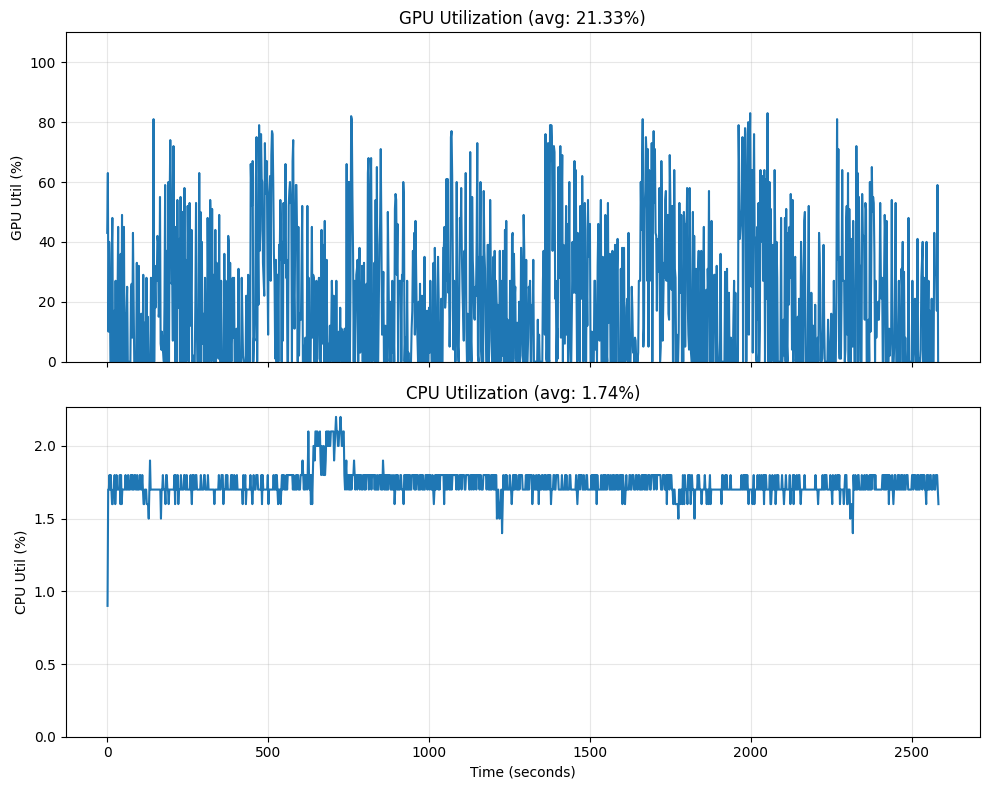

In [ ]:
# 8 workers
plot_cpu_gpu_timeline("basic_resources_stats_counter_19645886464755341_batch_size_32.csv")

881 881


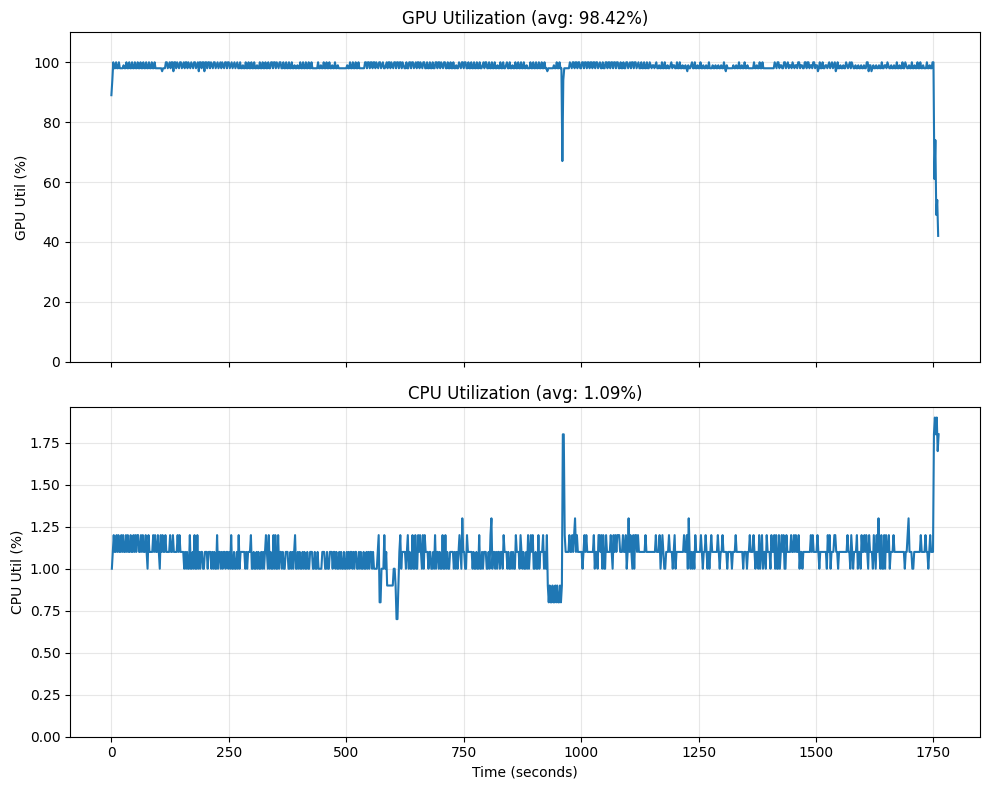

In [13]:
# 8 workers
plot_cpu_gpu_timeline("basic_resources_stats_counter_19646974531873102_batch_size_64.csv")

433 433


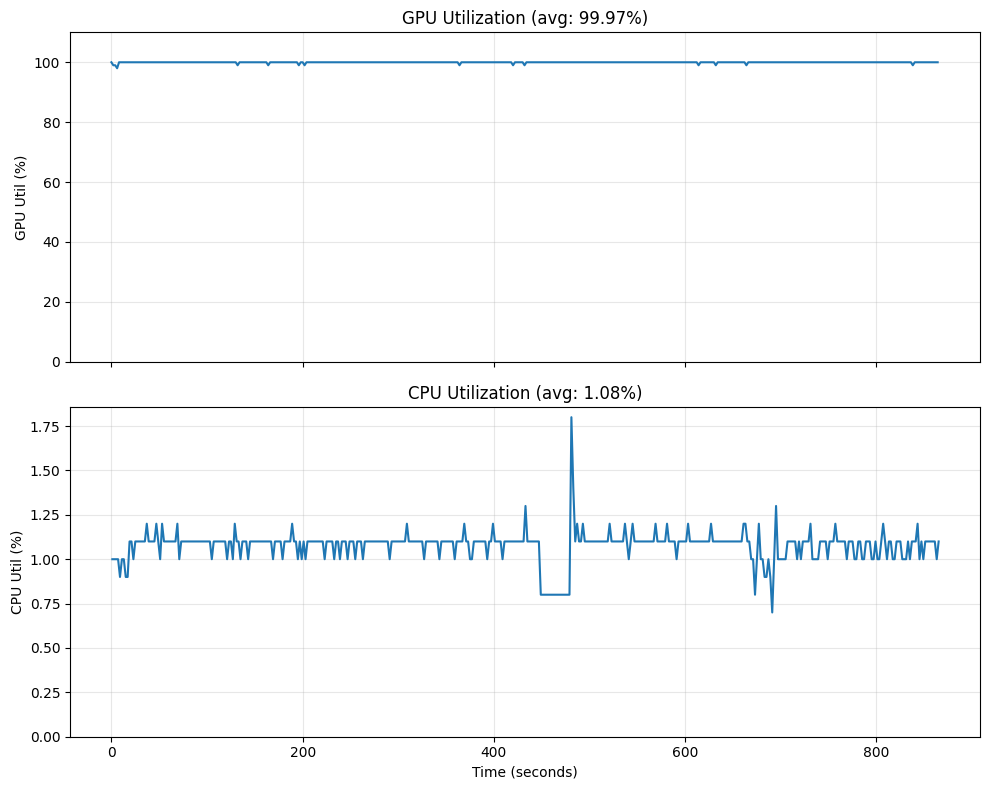

In [14]:
# 8 workers
plot_cpu_gpu_timeline("basic_resources_stats_counter_19647292308683795_batch_size_128.csv")

1696 1696


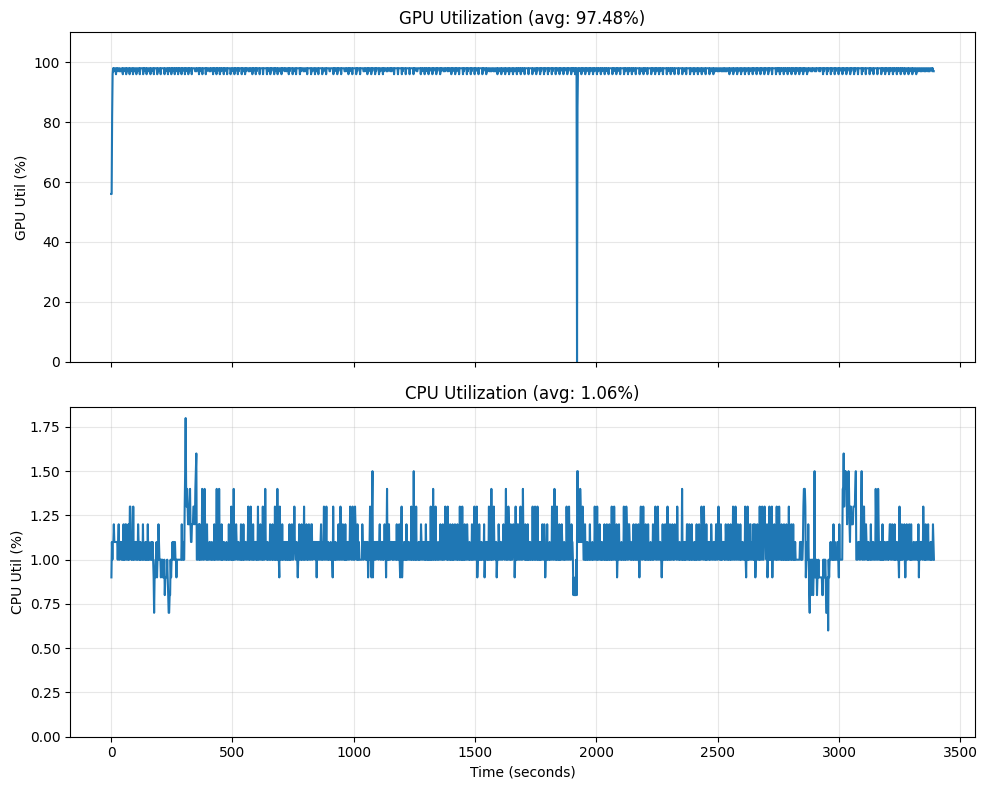

In [15]:
# 4 workers
plot_cpu_gpu_timeline("basic_resources_stats_counter_19647735891455734_batch_size_32.csv")

881 881


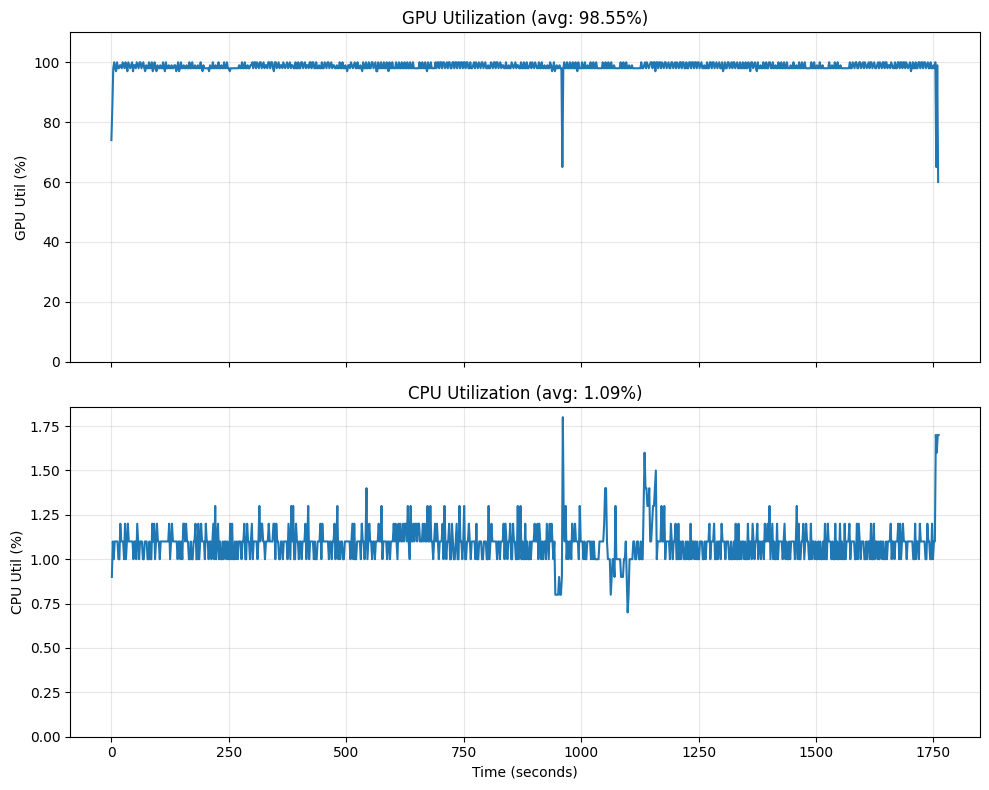

In [16]:
# 4 workers
plot_cpu_gpu_timeline("basic_resources_stats_counter_19648044583617427_batch_size_64.csv")

442 442


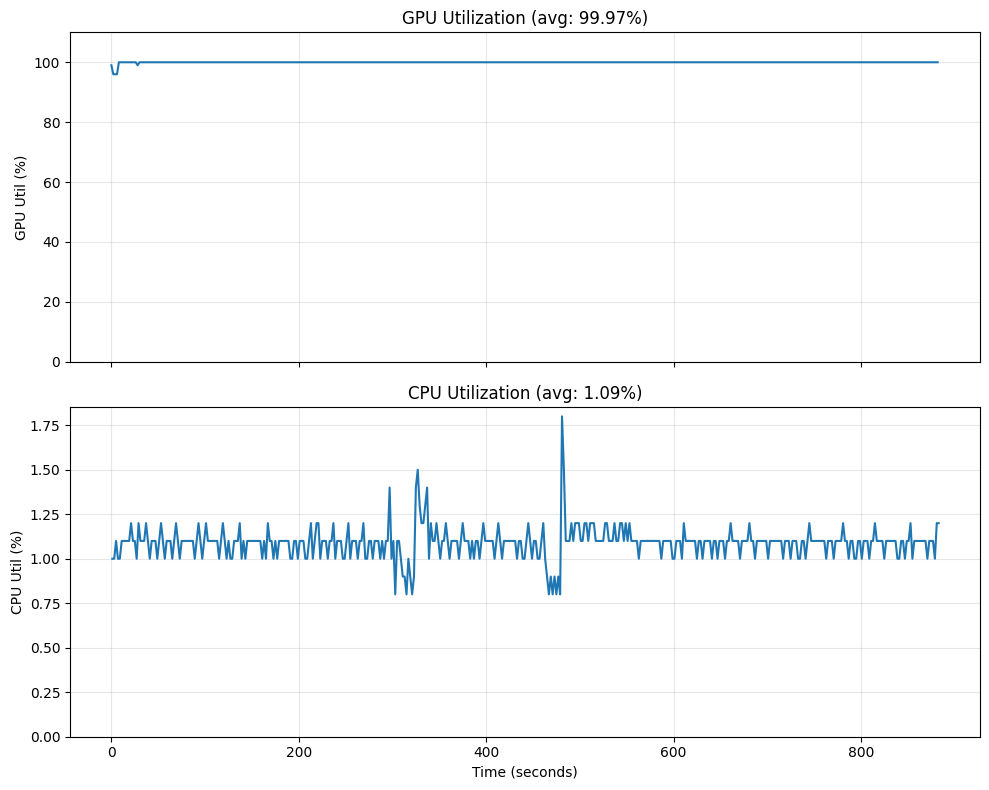

In [17]:
# 4 workers
plot_cpu_gpu_timeline("basic_resources_stats_counter_19648357904144067_batch_size_128.csv")

1693 1693


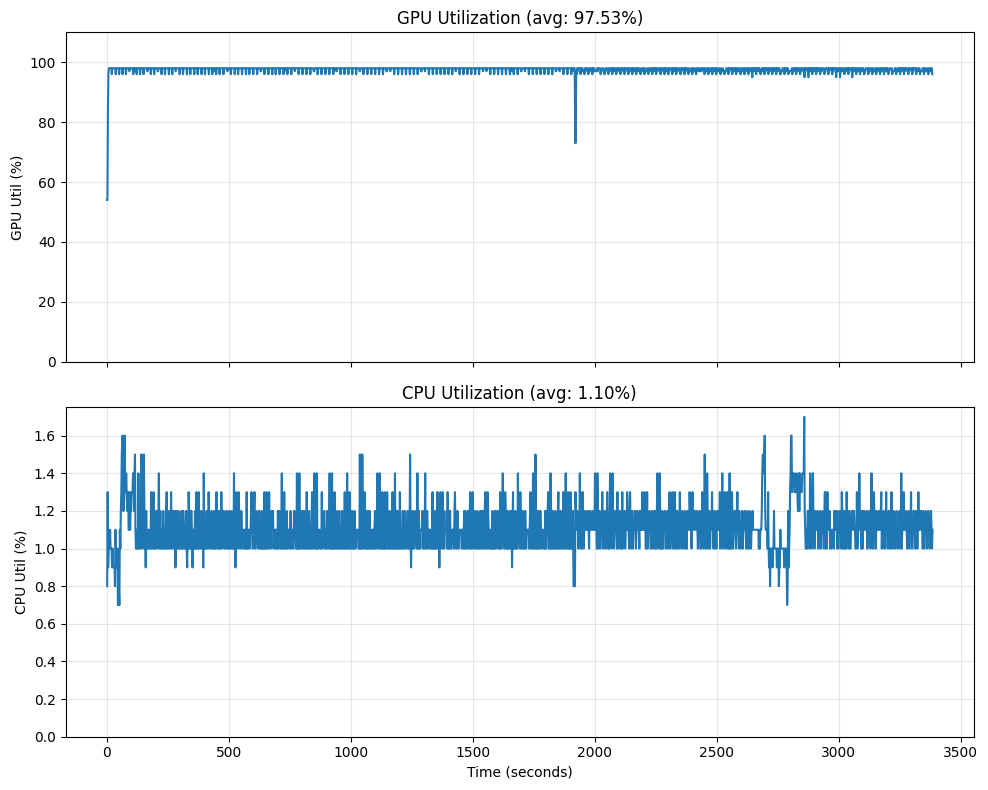

In [18]:
# 2 workers
plot_cpu_gpu_timeline("basic_resources_stats_counter_19648699761156124_batch_size_32.csv")

1920 1920


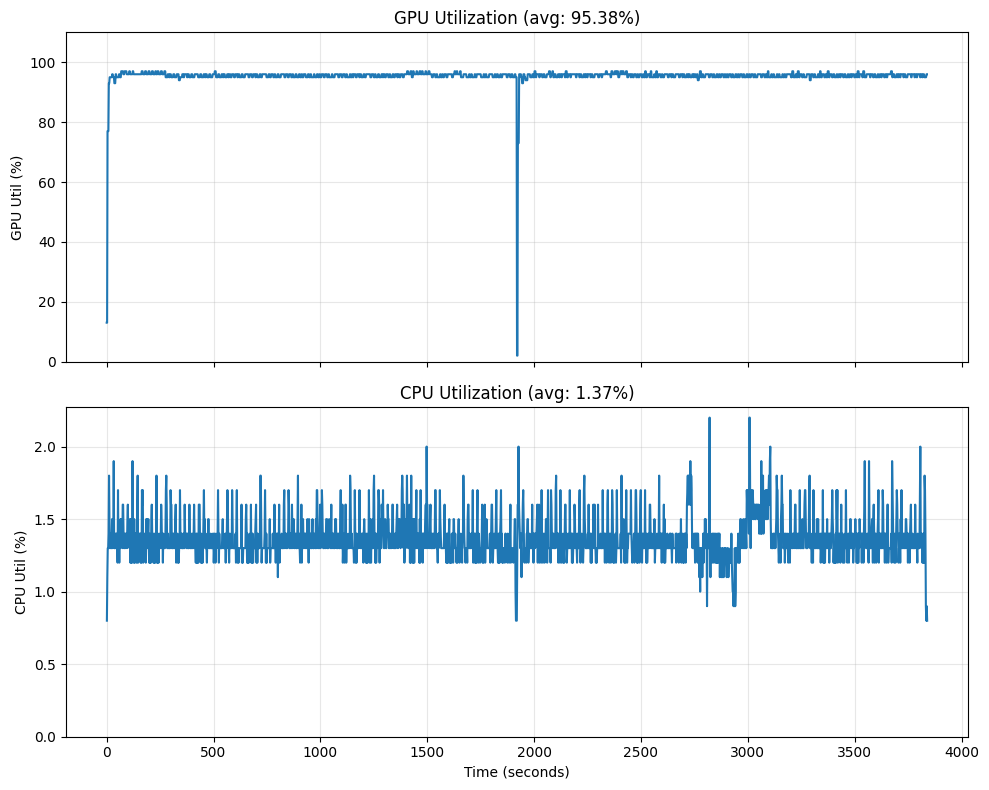

In [19]:
# resnet50, 2 workers
plot_cpu_gpu_timeline("basic_resources_stats_counter_19649963603902483_batch_size_32.csv")

960 960


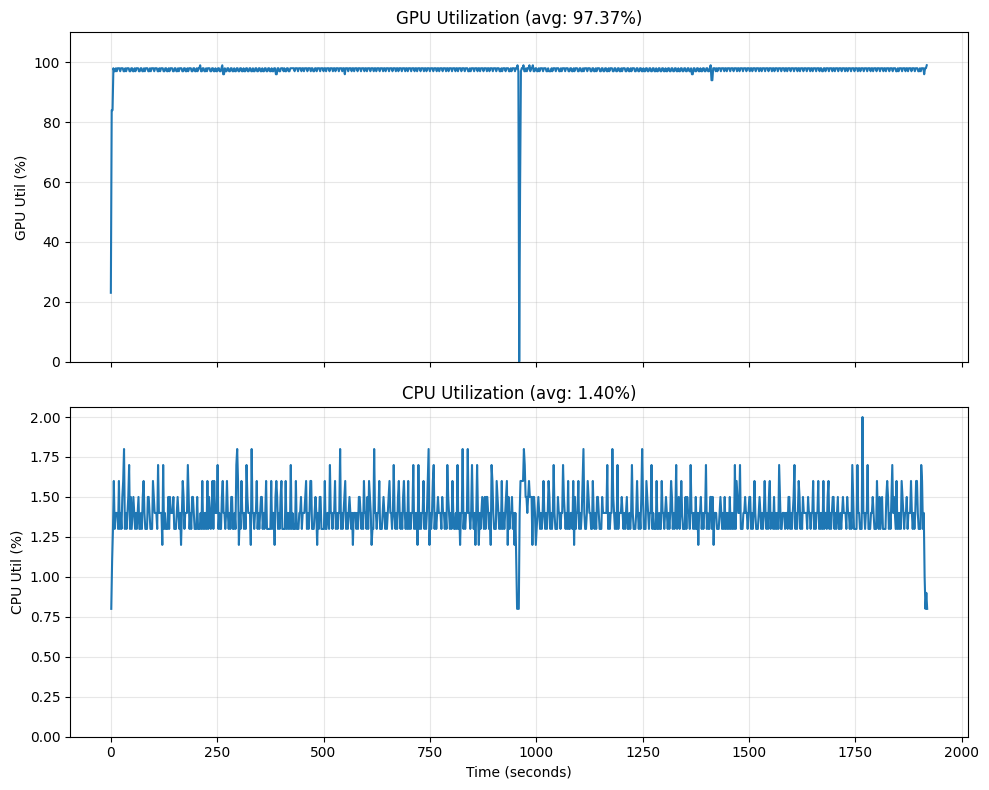

In [20]:
# resnet50, 2 workers
plot_cpu_gpu_timeline("basic_resources_stats_counter_19650123077475608_batch_size_64.csv")

480 480


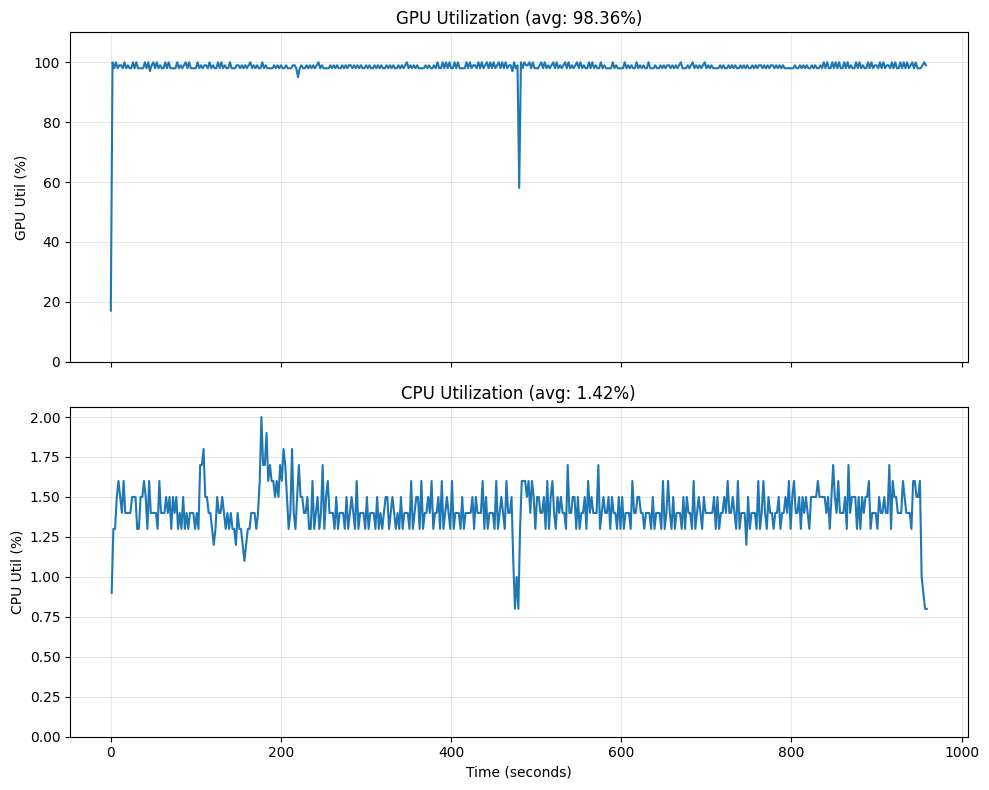

In [21]:
# resnet50, 2 workers
plot_cpu_gpu_timeline("basic_resources_stats_counter_19650276865609206_batch_size_128.csv")